In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import time
import numpy as np
import cv2 # yes, you can do this, but see below!
import os
%matplotlib inline

In [ ]:
import matplotlib.gridspec as gridspec

def plot_images(images, ncols=1):
    nrows = (len(images) // ncols) + 1
    figure = plt.figure(figsize=(ncols * 3, nrows * 2))
    gs = gridspec.GridSpec(nrows, ncols, figure=figure)

    for idx, image in enumerate(images):
        axes = figure.add_subplot(gs[idx // ncols, idx % ncols])
        axes.imshow(image, cmap='gray')
        axes.axis('off')
    plt.tight_layout()
    plt.show()


In [24]:
%pip install scipy
from scipy.ndimage import maximum_filter


def conv_2d(img, kernel, use_vectorized=True):
    """
    Implements a 2D convolution operation on an image with a given kernel.
    """
    # Get kernel dimensions
    k_height, k_width = kernel.shape
    
    # Calculate padding size
    pad_h = k_height // 2
    pad_w = k_width // 2
    
    # Pad the image with zeros around the borders to handle boundary conditions
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    if use_vectorized:
        # Vectorized implementation for better performance
        from numpy.lib.stride_tricks import sliding_window_view
        
        # Create a view of all possible windows in the padded image
        # This creates a 4D array where each element represents a window of size
        windows = sliding_window_view(padded, (k_height, k_width))
        
        # Use Einstein summation to efficiently compute element-wise multiplication and sum
        output = np.einsum('ijkl,kl->ij', windows, kernel)
    else:
        # Traditional loop-based implementation (slower but more intuitive)
        output = np.zeros_like(img, dtype=np.float64)
        
        # Iterate through each pixel of the image
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                # Apply the kernel at each position by multiplying and summing
                output[i, j] = np.sum(padded[i:i+k_height, j:j+k_width] * kernel)
    return output


def cornerDetect(img, winSize=7) -> np.array:
    """
    Corner detection function using either minimum eigenvalue or Harris measure.
    """
    
    # Define Sobel kernels for gradient computation
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    # Step 1: Apply Sobel kernels to get image derivatives
    Ix = conv_2d(img, sobel_x)  # Horizontal gradient
    Iy = conv_2d(img, sobel_y)  # Vertical gradient

    # Compute products of derivatives for structure tensor
    Ix2 = Ix ** 2  # Ix squared
    Iy2 = Iy ** 2  # Iy squared
    Ixy = Ix * Iy   # Ix * Iy

    # Define summation window 
    window = np.ones((winSize, winSize))
    
    # Step 2: Sum up components over the window to get structure tensor elements
    Sx2 = conv_2d(Ix2, window)  # Sum of Ix²
    Sy2 = conv_2d(Iy2, window)  # Sum of Iy²
    Sxy = conv_2d(Ixy, window)  # Sum of Ix*Iy

    # Calculate trace and determinant of the structure tensor
    traceM = Sx2 + Sy2  
    detM = Sx2 * Sy2 - Sxy ** 2  

    k = 0.04  # Harris sensitivity parameter <--- but not for the Harris, but do they have harris method for numpy?
    corner_strength = detM - k * (traceM ** 2)

    return corner_strength


def nms(img, threshold, winSize=7) -> np.array:
    local_max = maximum_filter(img, size=winSize)
    nms_mask = (img == local_max) & (img > threshold)
    
    return nms_mask.astype(np.uint8) * 255


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
def loadImages(directory: str) -> np.array:
    """
    Load images, convert them to float and to grayscale. 

    Returns:
        np.array: list of images.
    """

    images = []
    filenames = filter(lambda x: x.endswith('.jpg'), os.listdir(directory))
    for filename in filenames:
        filepath = os.path.join(directory, filename)
        image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (1000, 800)) 
        image = image.astype(np.float32) / 255.0  # Normalize
        images.append(image)
    return images


def getFeaturePoints(image, threshold=0.01, winSize=7, plot=True) -> np.array:
    """
    Detect feature points in an image, using the (Harris) corner detector you developed in Assignment 3.
    Do not forget non-maximum-suppression if you did not implement it. 
    Save the resulting corner points in a list and return. 
    The function should also plot the detected feature points in the image by default.
    """
    corners = cornerDetect(image, winSize=winSize)
    nms_mask = nms(corners, threshold=threshold, winSize=winSize)
    if plot:
        plot_images([nms_mask], ncols=1)

    return nms_mask


def getFeatureDescriptors(mode='pixels') -> np.array:
    """
    If mode is 'pixels':
      for a given input list of feature points on a given image, 
      extract their neighborhoods using the pixel values in a small window 
      around each point as afeature vector. 
      The window size needs to be a parameter of the function. 
      
    If the mode is 'gradients:
      for a given input list of feature points and a given image, 
      create a histogram of gradient directions in a small window 
      around each point [see class slides - you will need to first calculate 
      the direction of the gradient at each pixel in the given image, 
      window size is a parameter again, use 18 bins for the histogram]. 

    Returns:
        the feature vectors [pixels] as another list.
    """


def match2Images():
    """
    Given lists of feature points and feature descriptors from two images,
    match them. For this, compute distances between every descriptor in one
    image and every descriptor in the other image – Euclidean distance may work, but
    more robust matching can be done with normalized cross correlation (look it up, it’s
    easy!) of the pixel descriptors. Implement both ways and check later which gives
    better results. Select matches based on the ratio criterion with a suitable threshold
    (the threshold will be a function parameter!). The function should also plot the
    matches between the two images. Return the matches as a list of indices in the two
    images.
    """


def refineMatches():
    """
    Given lists of feature points and the match list, implement
    RANSAC to estimate a homography mapping one image onto the other (so, the full
    number of 8 parameters). In each iteration of RANSAC, simply select 4 points at
    random, estimate the homography by finding the nullspace of the transform (see
    lectures). This function also needs input parameters for inlier thresholds and rounds
    of iterations with which you need to experiment. Return the estimated
    homography. When running the function, it should print out the number of inliers
    that survive RANSAC and the average residual for the inliers (squared distance
    between the point coordinates in one image and the transformed coordinates of the
    matching point in the other image). Finally, the function should plot the surviving
    matches.
    """


def warpImages():
    """
    given a list of homographies and a list of n images, warp images 2-n
    onto the image space of image 1. For this, you are allowed to use the OpenCV
    function warpPerspective, which will work with your estimated homography
    (take care though in which direction you estimated the homography!!). In the
    function you will need to first create a new image big enough to hold all stitched
    images and then use warpPerspective to composite the two images into it. Use
    averaging of pixels for the stitching. Return the full stitched image and have the
    function also plot the result.
    """

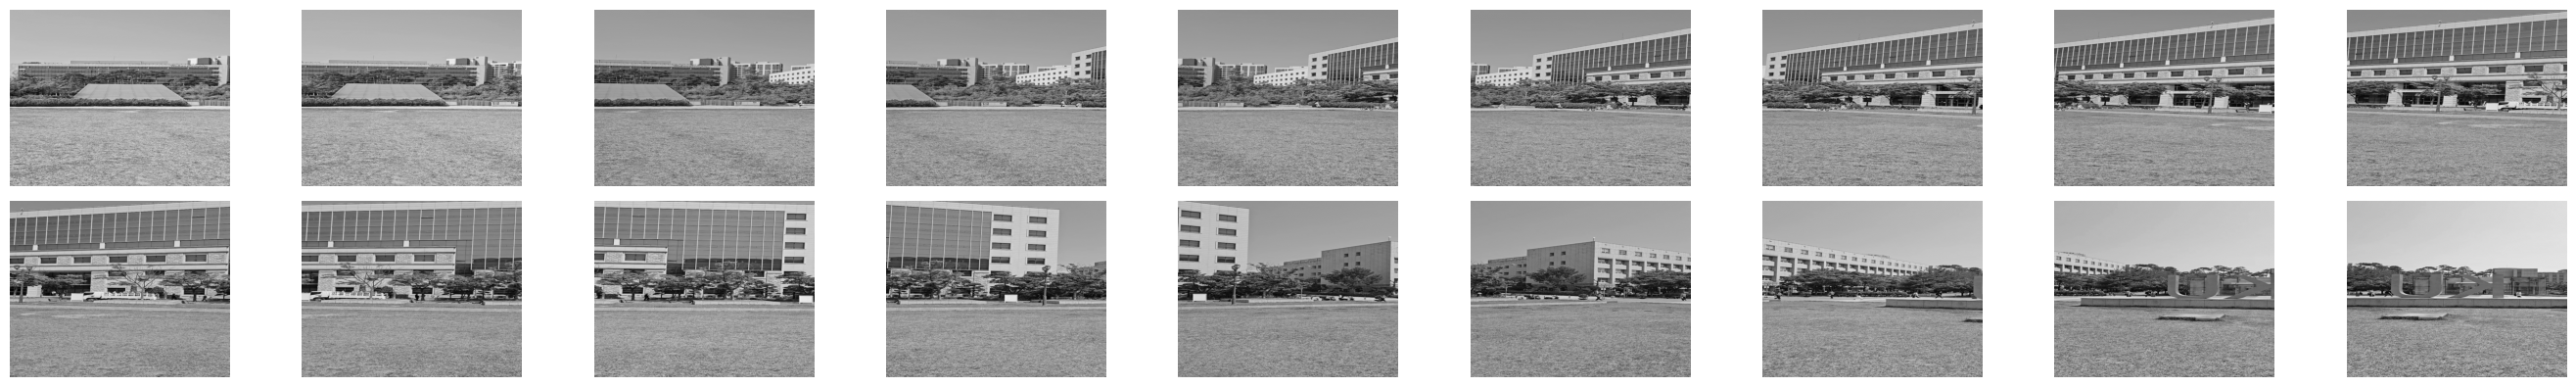

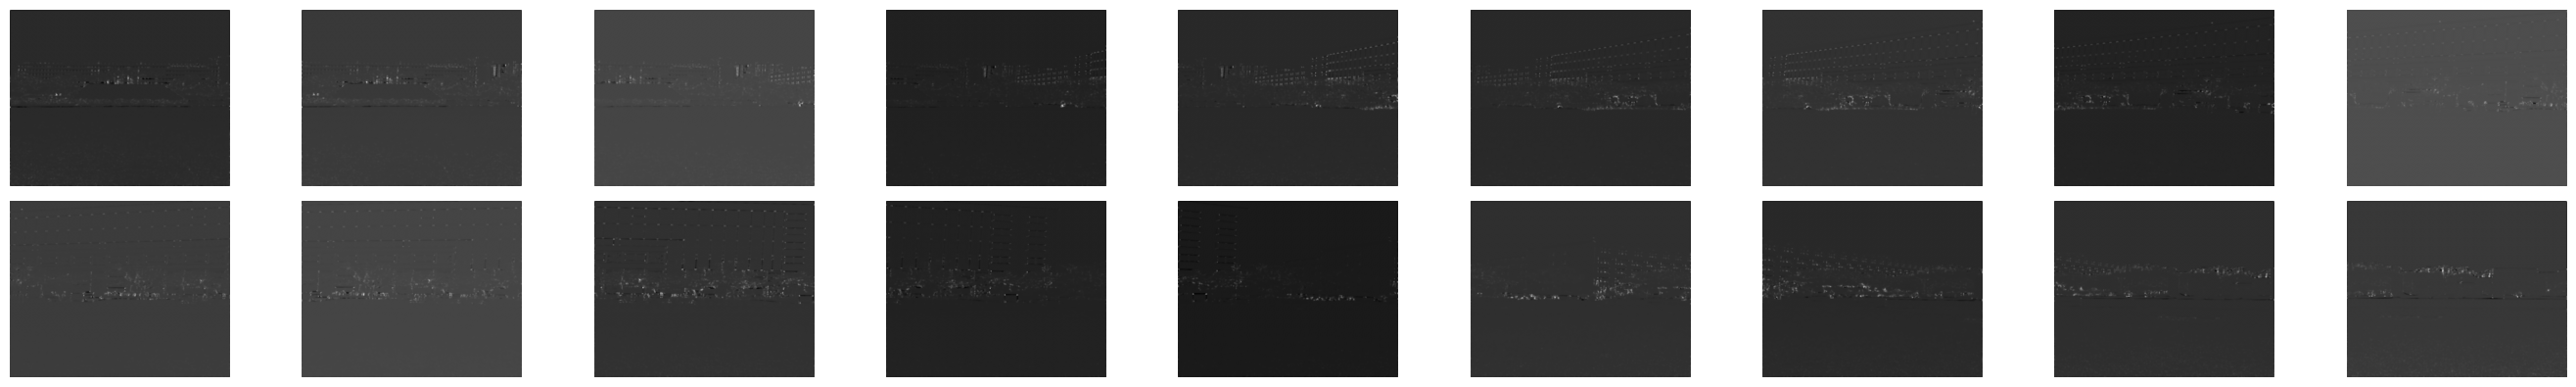

In [57]:
def main():
    images = loadImages("./assets")

    plot_images(images, ncols=9)
    
    feature_points = [getFeaturePoints(image, threshold=1e-5, winSize=7, plot=False) for image in images]
    plot_images(feature_points, ncols=9)
    

main()